Prac 3A

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("housing.csv")
# Display First Five Records
print(df.head())
# Display Numerical Columns
print(df.select_dtypes(include="number").columns)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
      

In [3]:
# Calculate Correlation Matrix
correlation = df.corr(numeric_only=True)
print(correlation)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      -0.079809   
housing_

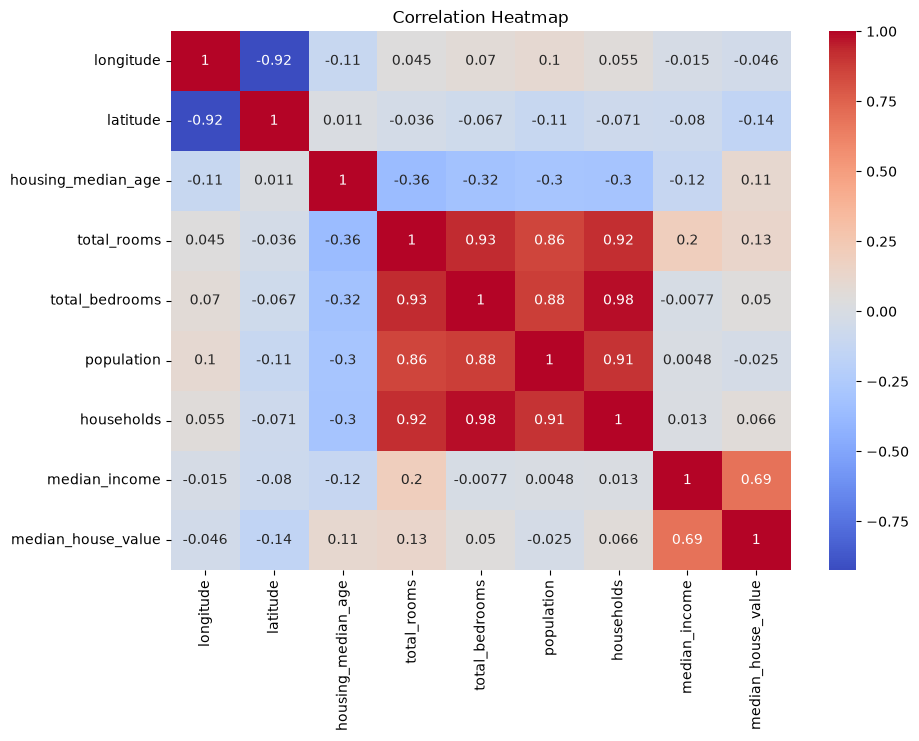

In [4]:
# Display Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

Prac 3B

In [5]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# Load Dataset
df = pd.read_csv("housing.csv")
# Select Independent and Dependent Variables
X = df[["median_income"]]
y = df["median_house_value"]
# Split Dataset into Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Create Linear Regression Model
model = LinearRegression()
# Train the Model
model.fit(X_train, y_train)
# Display Coefficient and Intercept
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 41933.84939381274
Intercept: 44459.729169078666


In [7]:
# Predict House Values
y_pred = model.predict(X_test)
# Display First 10 Predictions
print("Predicted Values:")
print(y_pred[:10])


Predicted Values:
[114958.91676996 150606.88213964 190393.71844449 285059.38345102
 200663.31816103 242165.24890609 257647.22610228 199229.18051176
 245893.1681172  384677.43607096]


In [8]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 7091157771.76555


In [9]:
# Calculate R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.45885918903846656


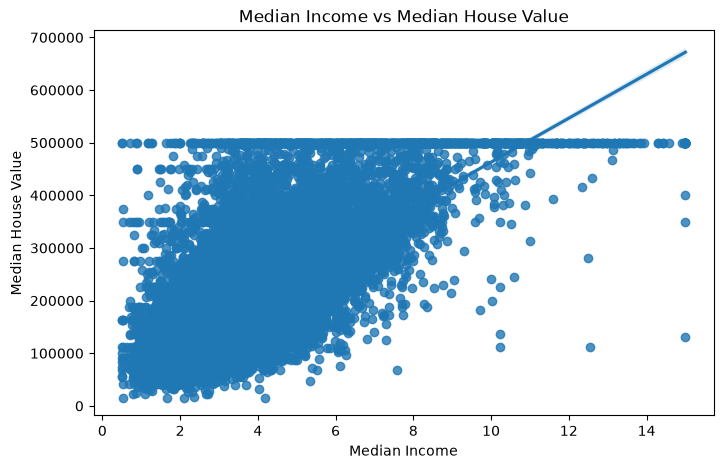

In [10]:
# Scatter Plot with Regression Line
plt.figure(figsize=(8, 5))
sns.regplot(
    x="median_income",
    y="median_house_value",
    data=df
)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()

In [17]:
# Complete Correlation Matrix
correlation = df.corr(numeric_only=True)
print("Complete Correlation Matrix:")
print(correlation)
# Get correlation pairs
pairs = correlation.where(
    ~pd.DataFrame(
        [[i >= j for j in range(len(correlation.columns))]
         for i in range(len(correlation.columns))],
        index=correlation.index,
        columns=correlation.columns
    )
).stack()
print("\nStrongest Positive Correlation:")
print(pairs.idxmax(), "=", pairs.max())
print("\nStrongest Negative Correlation:")
print(pairs.idxmin(), "=", pairs.min())
print("\nWeakest Correlation:")
weakest = pairs.abs().idxmin()
print(weakest, "=", pairs[weakest])

Complete Correlation Matrix:
                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.0710

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Independent variables
X = df[
    [
        "median_income",
        "housing_median_age",
        "total_rooms",
        "population",
        "households"
    ]
]
# Dependent variable
y = df["median_house_value"]
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Create and train model
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)
# Predict
y_pred_multiple = model_multiple.predict(X_test)
# Evaluate model
r2_multiple = r2_score(y_test, y_pred_multiple)
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
print("Multiple Linear Regression")
print("R2 Score:", r2_multiple)
print("Mean Squared Error:", mse_multiple)

Multiple Linear Regression
R2 Score: 0.5490012551168503
Mean Squared Error: 5909928044.702565


In [14]:
# Simple Regression Model
X_simple = df[["median_income"]]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)
y_pred_simple = model_simple.predict(X_test_s)
r2_simple = r2_score(y_test_s, y_pred_simple)
mse_simple = mean_squared_error(y_test_s, y_pred_simple)
print("\nSimple Regression Model")
print("R2 Score:", r2_simple)
print("Mean Squared Error:", mse_simple)
# Comparison
print("\n--- Model Comparison ---")
print("Simple Regression R2:", r2_simple)
print("Multiple Regression R2:", r2_multiple)
print("Simple Regression MSE:", mse_simple)
print("Multiple Regression MSE:", mse_multiple)


Simple Regression Model
R2 Score: 0.45885918903846656
Mean Squared Error: 7091157771.76555

--- Model Comparison ---
Simple Regression R2: 0.45885918903846656
Multiple Regression R2: 0.5490012551168503
Simple Regression MSE: 7091157771.76555
Multiple Regression MSE: 5909928044.702565


In [15]:
# Q.3 Correlation between Total Rooms and Median House Value
correlation_rooms = df["total_rooms"].corr(
    df["median_house_value"]
)
print("Correlation between total_rooms and median_house_value:")
print(correlation_rooms)

Correlation between total_rooms and median_house_value:
0.1341531138065631


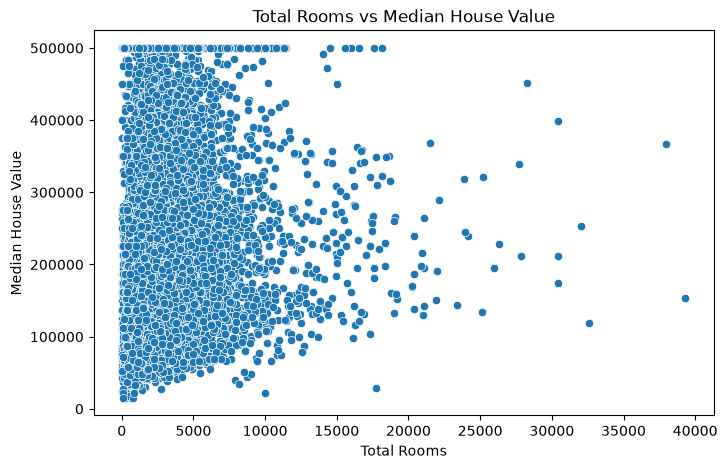

In [16]:
# Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="total_rooms",
    y="median_house_value",
    data=df
)
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.title("Total Rooms vs Median House Value")
plt.show()